# Tutorial: Cool Star Korg vs Jorg Comparison

Audience:
- Users who want to compare Jorg and Korg behavior for cool dwarfs.

Prerequisites:
- Run this notebook from the Jorg repository, or install `jorg` in your environment.
- Optional: Julia + Korg.jl for direct cross-checks.

Learning goals:
- Generate a cool-star synthetic spectrum with Jorg.
- Optionally run Korg.jl on the same setup.
- Quantify flux/continuum/rectified differences and inspect residuals.


## Outline

1. Configure cool-star parameters.
2. Run Jorg synthesis (with-lines and continuum-only).
3. Optionally run Korg.jl with the same parameters.
4. Compare metrics and visualize residuals.
5. Inspect local MARCS temperature coverage.


In [1]:
# Step 1: Cool-star parameters
Teff = 3000.0   # Try 3500.0 for a warmer cool star
logg = 4.6
m_H = 0.0
wl_min = 5000.0
wl_max = 5020.0
hydrogen_lines = False
cntm_step = 1.0

# Keep a stable tag for saved outputs
tag = f"Teff{Teff:.0f}_g{logg:.2f}_mH{m_H:.2f}".replace('.', 'p').replace('-', 'm')
tag


'Teff3000_g4p60_mH0p00'

In [2]:
# Step 2: Setup imports and paths
import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent:
    src_path = repo_root / "src"
    if (src_path / "jorg").exists():
        if str(src_path) not in sys.path:
            sys.path.insert(0, str(src_path))
        data_dir = repo_root / "data"
        if data_dir.exists():
            os.environ.setdefault("JORG_DATA_DIR", str(data_dir))
        break
    repo_root = repo_root.parent

from jorg.data import get_data_path
from jorg.atmosphere import interpolate_marcs
from jorg.lines.linelist import read_linelist
from jorg.synthesis import synthesize, create_korg_compatible_abundance_array

linelist_path = get_data_path("vald_extract_stellar_solar_threshold001.vald", must_exist=False)
if not linelist_path.exists():
    raise FileNotFoundError("VALD linelist not found. Set JORG_DATA_DIR to your data bundle.")

korg_script = os.environ.get("KORG_JL_SCRIPT")
if korg_script is None:
    candidate = repo_root / "examples" / "korg_compare_params.jl"
    if candidate.exists():
        korg_script = str(candidate)

out_dir = repo_root / "examples" / "comparison_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

print("repo_root:", repo_root)
print("linelist:", linelist_path)
print("korg_script:", korg_script)
print("out_dir:", out_dir)


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


repo_root: /Users/jdli/Project/jorg/jorg
linelist: /Users/jdli/Project/jorg/jorg/data/vald_extract_stellar_solar_threshold001.vald
korg_script: /Users/jdli/Project/jorg/jorg/examples/korg_compare_params.jl
out_dir: /Users/jdli/Project/jorg/jorg/examples/comparison_outputs


In [3]:
# Step 3: Run Jorg synthesis
linelist = read_linelist(str(linelist_path), format="vald")
atm = interpolate_marcs(Teff, logg, m_H)
A_X = create_korg_compatible_abundance_array(m_H)

result_lines = synthesize(
    atm,
    linelist,
    A_X,
    wavelengths=(wl_min, wl_max),
    hydrogen_lines=hydrogen_lines,
    verbose=False,
    logg=logg,
    cntm_step=cntm_step,
)
result_cntm = synthesize(
    atm,
    [],
    A_X,
    wavelengths=(wl_min, wl_max),
    hydrogen_lines=hydrogen_lines,
    verbose=False,
    logg=logg,
    cntm_step=cntm_step,
)

wl = np.asarray(result_lines.wavelengths)
flux = np.asarray(result_lines.flux)
cntm = np.asarray(result_lines.cntm)
rect = flux / cntm

wl_c = np.asarray(result_cntm.wavelengths)
flux_c = np.asarray(result_cntm.flux)
cntm_c = np.asarray(result_cntm.cntm)
rect_c = flux_c / cntm_c

np.savetxt(out_dir / f"jorg_{tag}_spectrum_with_lines.txt", np.column_stack([wl, flux, cntm, rect]))
np.savetxt(out_dir / f"jorg_{tag}_spectrum_continuum.txt", np.column_stack([wl_c, flux_c, cntm_c, rect_c]))
np.savetxt(out_dir / f"jorg_{tag}_alpha_with_lines.txt", np.asarray(result_lines.alpha))
np.savetxt(out_dir / f"jorg_{tag}_alpha_continuum.txt", np.asarray(result_cntm.alpha))

print("Jorg arrays:", wl.shape, flux.shape, cntm.shape)
print("Rectified range:", float(rect.min()), float(rect.max()))


📖 Reading linelist: vald_extract_stellar_solar_threshold001.vald
   Format: vald
   Wavelength unit: auto
   Detected vacuum wavelengths - no conversion needed
   Found 41880 data lines
   Successfully parsed 41861 lines
   After Korg.jl filtering: 41861 lines (removed 0 lines)


2026-02-09 13:53:23.195567: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %pad.433 = f64[11,9,15,5,13,5,81]{6,5,4,3,2,1,0} pad(f64[1,9,15,5,13,5,81]{6,5,4,3,2,1,0} %constant.11783, f64[] %constant.307), padding=0_10x0_0x0_0x0_0x0_0x0_0x0_0, metadata={op_name="jit(_interp)/jit(main)/jit(cubic_spline_nd)/jit(cubic_spline_coefficients)/jit(_solve_tridiagonal_jax)/scatter[update_consts=() dimension_numbers=ScatterDimensionNumbers(update_window_dims=(0, 1, 2, 3, 4, 5), inserted_window_dims=(0,), scatter_dims_to_operand_dims=(0,)) indices_are_sorted=True unique_indices=True mode=GatherScatterMode.FILL_OR_DROP]" source_file="/Users/jdli/Project/jorg/jorg/src/jorg/interpolation_jax.py" source_line=135}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be 

Loaded 273 EXACT partition functions from Korg.jl
  Added bare nuclei: H II, He III (U=1)
Jorg arrays: (2001,) (2001,) (2001,)
Rectified range: 0.0034187950732467395 0.9642980833937526


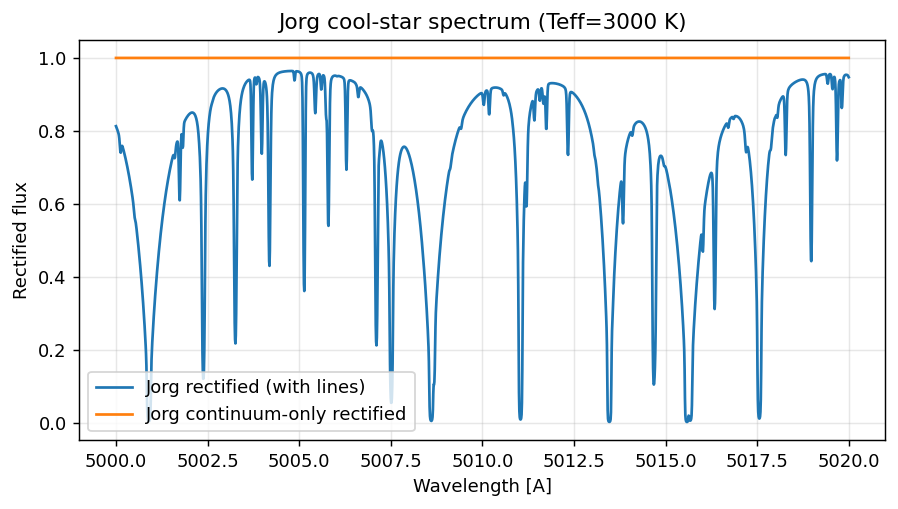

In [4]:
# Quick look at Jorg outputs
plt.figure(figsize=(8, 4), dpi=130)
plt.plot(wl, rect, label="Jorg rectified (with lines)")
plt.plot(wl_c, rect_c, label="Jorg continuum-only rectified")
plt.xlabel("Wavelength [A]")
plt.ylabel("Rectified flux")
plt.title(f"Jorg cool-star spectrum (Teff={Teff:.0f} K)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [5]:
# Step 4 (optional): Run Korg.jl on the same parameters
JULIA_BIN = os.environ.get("JULIA_BIN", "julia")

if not korg_script:
    print("Skipping Korg synthesis: set KORG_JL_SCRIPT or keep examples/korg_compare_params.jl available.")
else:
    script_path = Path(korg_script)
    if not script_path.exists():
        print(f"Skipping Korg synthesis: script not found -> {script_path}")
    else:
        cmd = [
            JULIA_BIN,
            f"--project={script_path.parent}",
            str(script_path),
            str(Teff),
            str(logg),
            str(m_H),
            str(wl_min),
            str(wl_max),
            tag,
            str(out_dir),
        ]
        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode != 0:
            print(proc.stdout)
            print(proc.stderr)
            raise RuntimeError(f"Korg failed with code {proc.returncode}")
        print(proc.stdout)


Constructing cool dwarf atmosphere interpolator.  This will only happen once per process...
Wrote:
  /Users/jdli/Project/jorg/jorg/examples/comparison_outputs/korg_Teff3000_g4p60_mH0p00_spectrum_with_lines.txt
  /Users/jdli/Project/jorg/jorg/examples/comparison_outputs/korg_Teff3000_g4p60_mH0p00_spectrum_continuum.txt



In [6]:
# Step 5: Load Korg outputs (if present) and compare metrics
k_lines_path = out_dir / f"korg_{tag}_spectrum_with_lines.txt"
k_cntm_path = out_dir / f"korg_{tag}_spectrum_continuum.txt"
j_lines_path = out_dir / f"jorg_{tag}_spectrum_with_lines.txt"
j_cntm_path = out_dir / f"jorg_{tag}_spectrum_continuum.txt"

if not (k_lines_path.exists() and k_cntm_path.exists()):
    print("Korg outputs not found. Run the previous cell with Julia/Korg enabled.")
    korg_loaded = False
else:
    korg_loaded = True
    k_lines = np.loadtxt(k_lines_path)
    j_lines = np.loadtxt(j_lines_path)
    k_cntm = np.loadtxt(k_cntm_path)
    j_cntm = np.loadtxt(j_cntm_path)

    n = min(len(k_lines), len(j_lines))
    k_lines = k_lines[:n]
    j_lines = j_lines[:n]

    eps = 1e-30
    flux_ratio = np.mean(j_lines[:, 1] / np.maximum(k_lines[:, 1], eps))
    cntm_ratio = np.mean(j_lines[:, 2] / np.maximum(k_lines[:, 2], eps))
    rect_abs_mae = np.mean(np.abs(j_lines[:, 3] - k_lines[:, 3]))
    rect_rel_mae = np.mean(np.abs(j_lines[:, 3] - k_lines[:, 3]) / np.maximum(np.abs(k_lines[:, 3]), eps))

    print(f"points compared: {n}")
    print(f"mean flux ratio (Jorg/Korg): {flux_ratio:.6f}")
    print(f"mean continuum ratio (Jorg/Korg): {cntm_ratio:.6f}")
    print(f"rectified abs MAE: {rect_abs_mae:.6e}")
    print(f"rectified rel MAE: {rect_rel_mae:.6e}")


points compared: 2001
mean flux ratio (Jorg/Korg): 0.995937
mean continuum ratio (Jorg/Korg): 0.976067
rectified abs MAE: 1.108427e-02
rectified rel MAE: 2.303157e-02


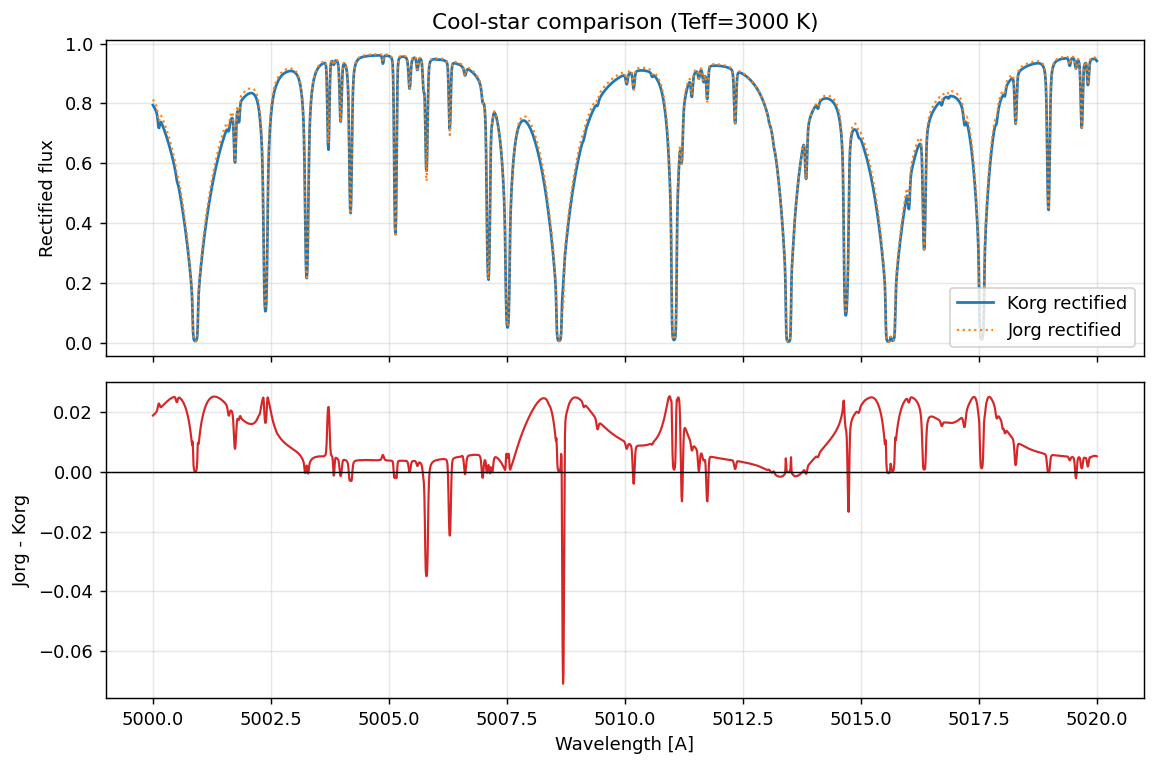

In [7]:
# Visualize Jorg-Korg residuals when Korg data is available
if not korg_loaded:
    print("No Korg outputs loaded; skip plotting residuals.")
else:
    wl_cmp = j_lines[:, 0]
    rect_delta = j_lines[:, 3] - k_lines[:, 3]

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), dpi=130, sharex=True)
    axes[0].plot(wl_cmp, k_lines[:, 3], label="Korg rectified", linewidth=1.5)
    axes[0].plot(wl_cmp, j_lines[:, 3], label="Jorg rectified", linewidth=1.2, linestyle=':')
    axes[0].set_ylabel("Rectified flux")
    axes[0].set_title(f"Cool-star comparison (Teff={Teff:.0f} K)")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(wl_cmp, rect_delta, color="tab:red", linewidth=1.2)
    axes[1].axhline(0.0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Wavelength [A]")
    axes[1].set_ylabel("Jorg - Korg")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [8]:
# Step 6: Check local MARCS temperature limits used by this environment
import h5py

grid_candidates = [
    Path.home() / ".julia" / "artifacts" / "0e9cca0d99f7ad79aa966aa28c7be962071893e2" / "SDSS_MARCS_atmospheres" / "SDSS_MARCS_atmospheres.h5",
    Path.home() / ".julia" / "artifacts" / "cd6250126e449334f340641a545c2ab5c3d1bf7c" / "resampled_cool_dwarf_atmospheres" / "resampled_cool_dwarf_atmospheres.h5",
    Path.home() / ".julia" / "artifacts" / "7ccbdaf1a3709772953d75b0888e6d5ec359d90b" / "MARCS_metal_poor_atmospheres" / "MARCS_metal_poor_atmospheres.h5",
]

for grid_path in grid_candidates:
    if not grid_path.exists():
        print(f"missing: {grid_path}")
        continue
    with h5py.File(grid_path, "r") as f:
        names = [x.decode() if isinstance(x, bytes) else str(x) for x in f["grid_parameter_names"][()]]
        teff_index = names.index("Teff") + 1
        teff_vals = np.array(f["grid_values"][str(teff_index)])
        print(f"{grid_path.name}: Teff {teff_vals.min():.0f} - {teff_vals.max():.0f} K")


SDSS_MARCS_atmospheres.h5: Teff 2800 - 8000 K
resampled_cool_dwarf_atmospheres.h5: Teff 2800 - 4000 K
MARCS_metal_poor_atmospheres.h5: Teff 2500 - 8000 K


## Notes and extensions

Common pitfall:
- Forgetting that cool stars are sensitive to line blanketing and continuum normalization.
- Compare both `flux` and `flux/cntm`; a small opacity mismatch can look larger after rectification.

Suggested extension:
- Rerun with `Teff = 3500` and compare metrics side-by-side with `Teff = 3000`.
